# NLUM Land Use Cleaning (Colab)

This notebook downloads a public land use raster (NLUM), clips a small subset,
and cleans it using `multiclean.clean_array`.

In [ ]:
%pip -q install multiclean rasterio matplotlib

In [1]:
import zipfile
from pathlib import Path
import requests
import numpy as np
import matplotlib.pyplot as plt
import rasterio as rio
from multiclean import clean_array

DATA_URL = (
    "https://www.agriculture.gov.au/sites/default/files/documents/"
    "NLUM_v7_250_ALUMV8_2010_11_alb_package_20241128.zip"
)
WORKDIR = Path.cwd() / "nlum_data"
WORKDIR.mkdir(exist_ok=True)
ZIP_PATH = WORKDIR / "nlum.zip"
EXTRACT_DIR = WORKDIR / "extracted"
EXTRACT_DIR.mkdir(exist_ok=True)

print("Working directory:", WORKDIR)

Working directory: /Users/nick/Documents/Work Code/MultiClean/notebooks/nlum_data


In [2]:
# Download the NLUM zip
if not ZIP_PATH.exists():
    print("Downloading...", DATA_URL)
    with requests.get(DATA_URL, stream=True, timeout=120) as r:
        r.raise_for_status()
        with open(ZIP_PATH, "wb") as f:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)
    print("Saved to", ZIP_PATH)
else:
    print("Zip already exists at", ZIP_PATH)

# Extract
with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    zf.extractall(EXTRACT_DIR)
print("Extracted to", EXTRACT_DIR)

Downloading... https://www.agriculture.gov.au/sites/default/files/documents/NLUM_v7_250_ALUMV8_2010_11_alb_package_20241128.zip
Saved to /Users/nick/Documents/Work Code/MultiClean/notebooks/nlum_data/nlum.zip
Extracted to /Users/nick/Documents/Work Code/MultiClean/notebooks/nlum_data/extracted


In [3]:
# Locate the TIFF: NLUM_v7_250_ALUMV8_2010_11_alb.tif
candidates = list(EXTRACT_DIR.rglob("*.tif"))
if not candidates:
    raise FileNotFoundError("No .tif files found in extracted package")
# Prefer the expected filename if present
preferred = [p for p in candidates if "NLUM_v7_250_ALUMV8_2010_11_alb.tif" in p.name]
tif_path = preferred[0] if preferred else candidates[0]
print("Using TIFF:", tif_path)

with rio.open(tif_path) as src:
    full = src.read(1)  # 2D array of class labels

print("Raster shape:", full.shape, "dtype:", full.dtype)
print("Sample classes:", np.unique(full)[:15])

Using TIFF: /Users/nick/Documents/Work Code/MultiClean/notebooks/nlum_data/extracted/NLUM_v7_250_ALUMV8_2010_11_alb.tif
Raster shape: (15669, 18633) dtype: int16
Sample classes: [  0 111 112 113 114 115 116 117 120 125 130 131 132 133 134]


Subset shape: (200, 200)


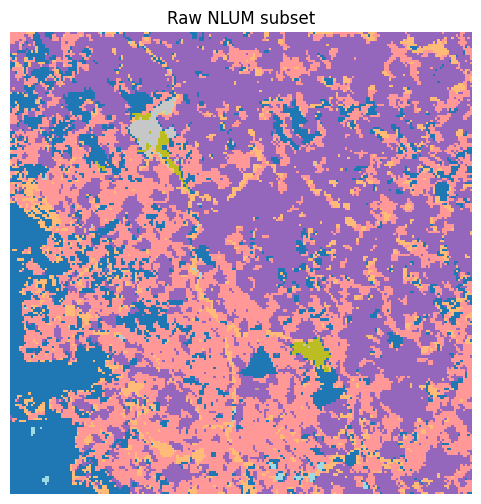

Unique classes in subset: [111 113 117 120 130 133 210 311 312 320 330 331 333 334 338 340 341 343
 349 431 443 520 522 526 530 534 541 543 551 552 553 571 593 630 650 651]


In [ ]:
# Create a 500x500 pixel subset
h, w = full.shape
win = 200
r0 = 10000
c0 = 3000
r1 = min(h, r0 + win)
c1 = min(w, c0 + win)
subset = full[r0:r1, c0:c1].astype(np.int32, copy=False)
print("Subset shape:", subset.shape)

# Visualize the raw subset
plt.figure(figsize=(6, 6))
plt.imshow(subset, cmap="tab20", interpolation="nearest")
plt.title("Raw NLUM subset")
plt.axis("off")
plt.show()
classes = np.unique(subset)
print("Unique classes in subset:", classes)

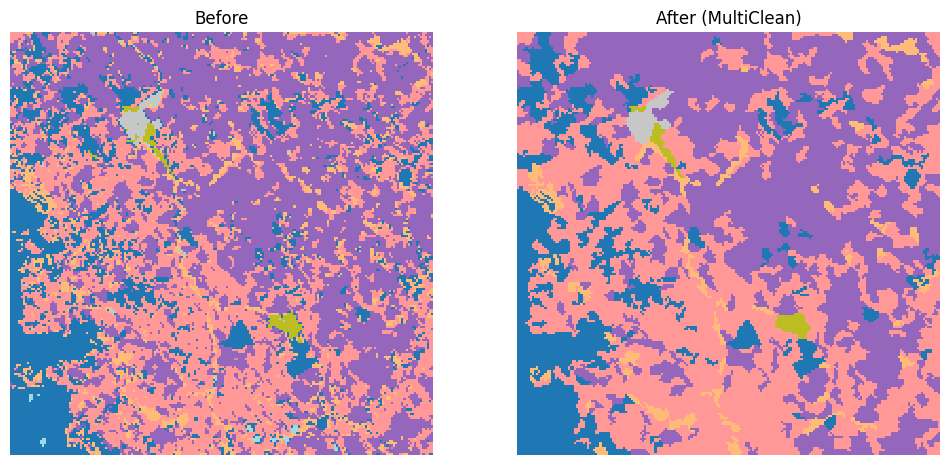

Unique classes after: [111 113 130 133 210 311 312 320 331 333 334 338 541 543 553]


In [48]:
# Clean the subset
cleaned = clean_array(
    array=subset,
    smooth_edge_size=1,
    min_island_size=10,
    connectivity=8,
)

# Compare before/after
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(
    subset, cmap="tab20", interpolation="nearest", vmin=min(classes), vmax=max(classes)
)
axes[0].set_title("Before")
axes[0].axis("off")
axes[1].imshow(
    cleaned, cmap="tab20", interpolation="nearest", vmin=min(classes), vmax=max(classes)
)
axes[1].set_title("After (MultiClean)")
axes[1].axis("off")
plt.show()

print("Unique classes after:", np.unique(cleaned))